In [19]:
import json
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

CSV_BID_FILE_SIZE = 6678514674        # bytes
CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_BID_FILE_SIZE = 15878100724      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def get_file_size(query, suite_name):
    is_json = "json" in suite_name.lower()
    if "bid" in query.lower():
        return JSON_BID_FILE_SIZE if is_json else CSV_BID_FILE_SIZE
    return JSON_PERSON_FILE_SIZE if is_json else CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name):
    with open(filepath) as f:
        data = json.load(f)
    rows = []
    for r in data:
        if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
            continue
        started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
        stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
        exec_time = (stopped - started).total_seconds()
        query = shorten_query(r["query"].strip())
        file_size = get_file_size(query, suite_name)
        rows.append({
            "suite": suite_name,
            "query": query,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776174789.json", "CSV baseline")
rows += load_suite("results/optimized_results_1776180206.json", "CSV optimized")
rows += load_suite("results/baseline-json_results_1776184671.json", "JSON baseline")
rows += load_suite("results/optimized-json_results_1776191158.json", "JSON optimized")
df = pd.DataFrame(rows)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 960
Suites: ['CSV baseline', 'CSV optimized', 'JSON baseline', 'JSON optimized']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Queries: ['SELECT * FROM person WHERE city == "redmond"', 'SELECT auctionId FROM bid WHERE bidder == 1001', 'SELECT id FROM person WHERE city == "redmond"', 'SELECT name FROM person WHERE city == "redmond"']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV baseline,"SELECT name FROM person WHERE city == ""redmond""",2,14.189,59.210012
1,CSV baseline,"SELECT name FROM person WHERE city == ""redmond""",2,14.288,58.799752
2,CSV baseline,"SELECT name FROM person WHERE city == ""redmond""",2,14.181,59.243414
3,CSV baseline,"SELECT name FROM person WHERE city == ""redmond""",2,14.151,59.369010
4,CSV baseline,"SELECT name FROM person WHERE city == ""redmond""",2,14.215,59.101714
...,...,...,...,...,...
955,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001,64,14.618,1035.882943
956,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001,64,14.800,1023.144382
957,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001,64,14.676,1031.789102
958,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001,64,15.194,996.612930


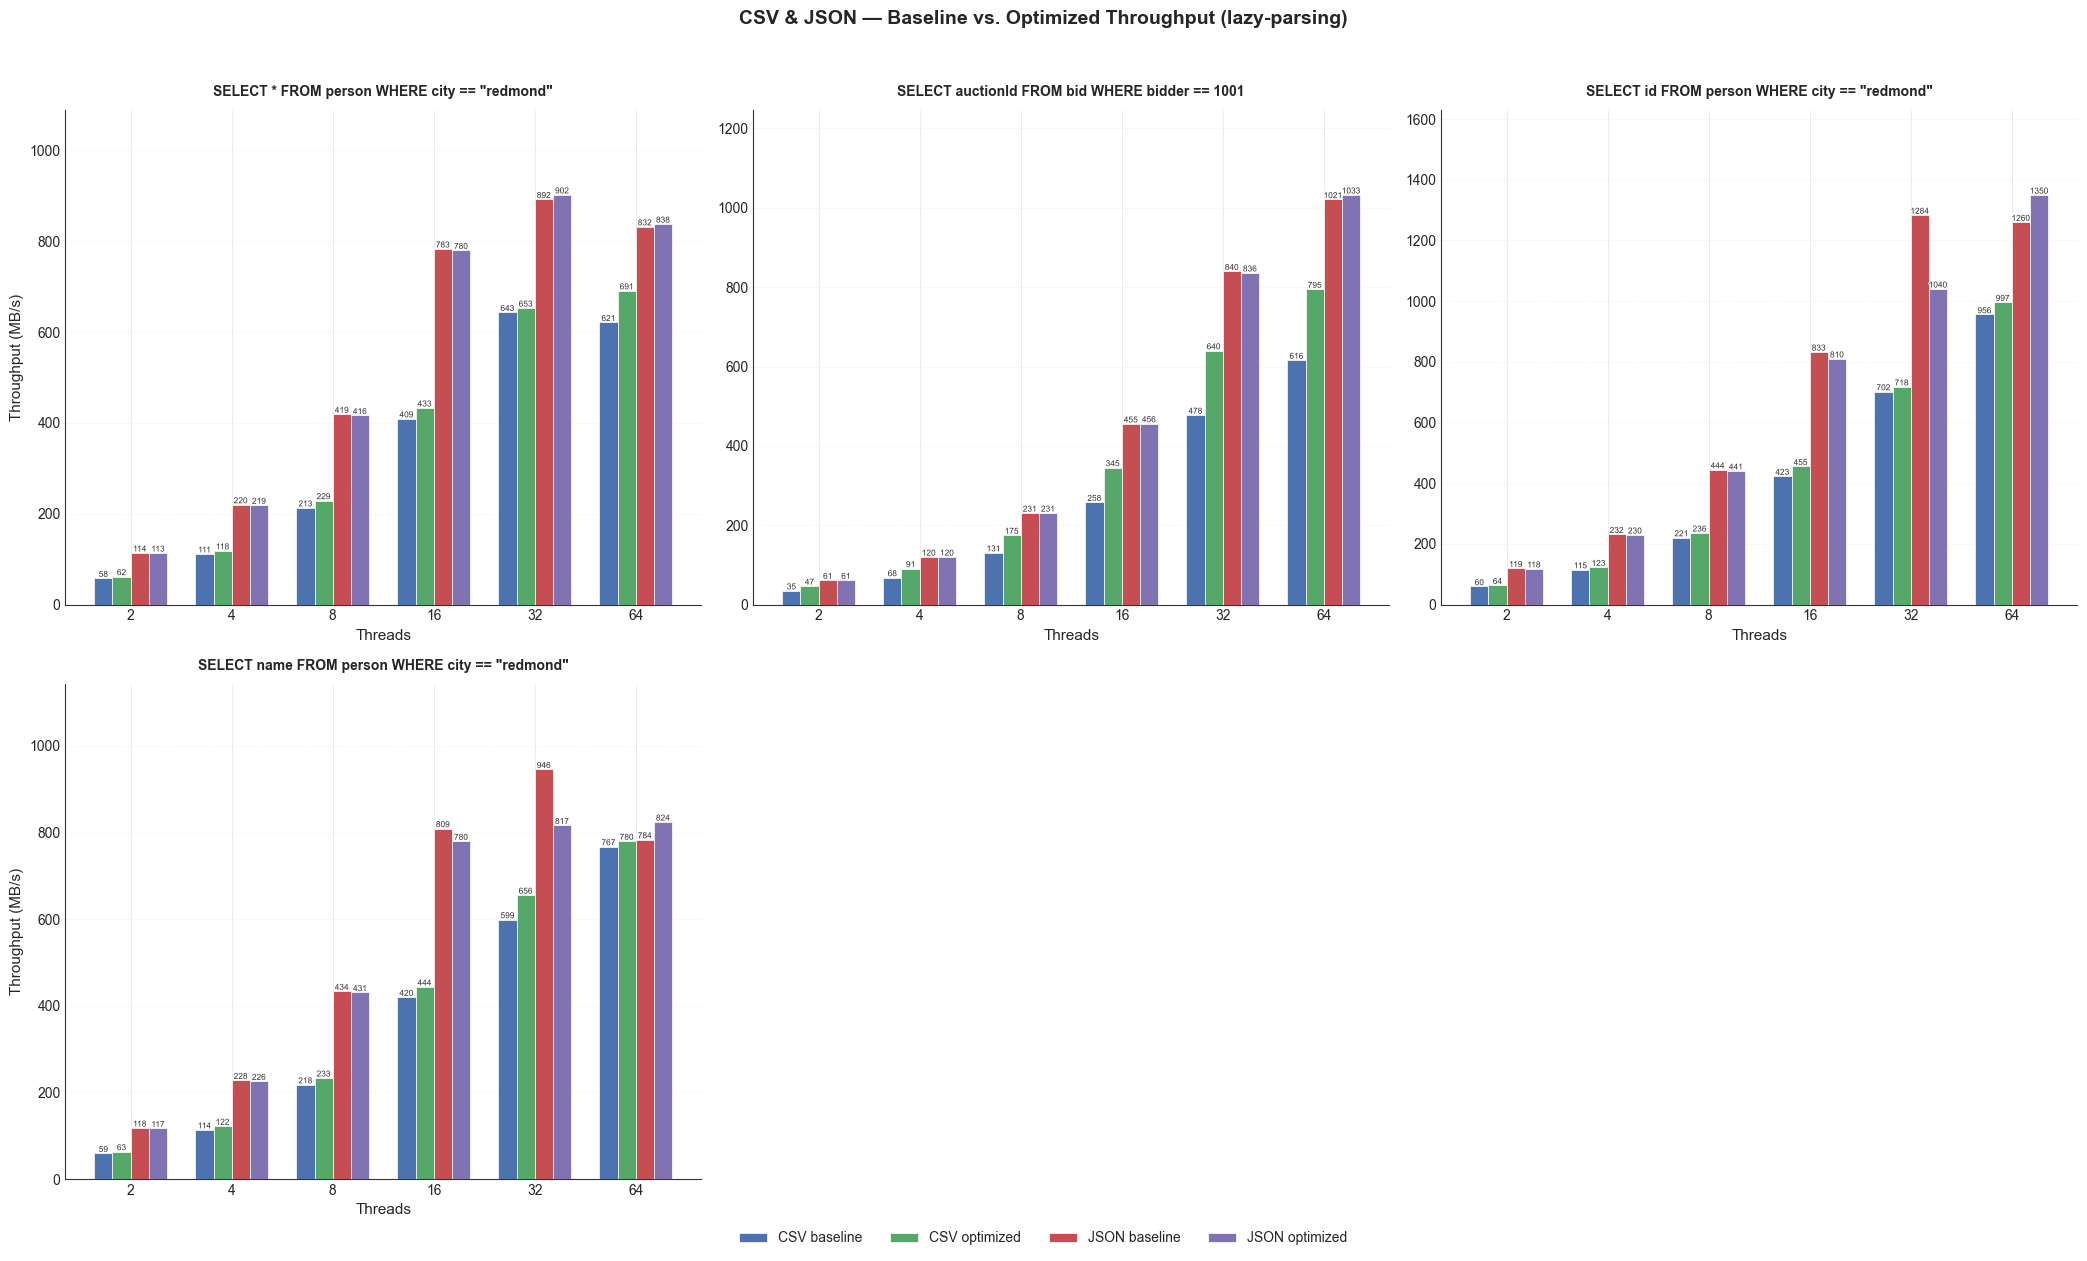

In [21]:
# Grouped bar chart: 4 suites per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

n_queries = len(queries)
n_cols = min(3, n_queries)
n_rows = (n_queries + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for idx, q in enumerate(queries):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                              f"{h:.0f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if col == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused subplots
for idx in range(n_queries, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("CSV & JSON \u2014 Baseline vs. Optimized Throughput (lazy-parsing)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

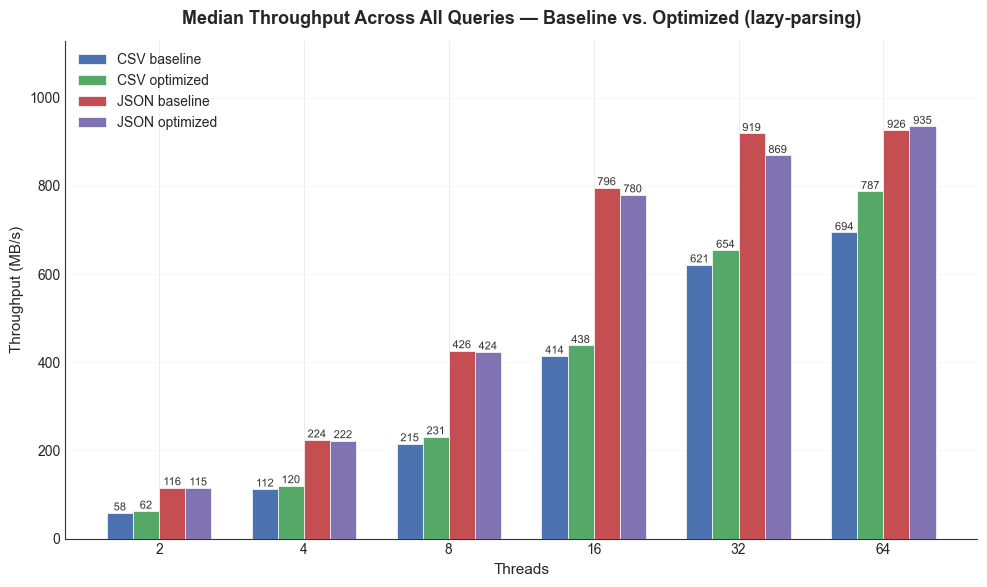

In [22]:
# Median throughput across all queries per suite & thread count
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

# For each (suite, threads) pair, first get per-query median, then median across queries
median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

fig, ax = plt.subplots(figsize=(10, 6))

for j, suite in enumerate(suites):
    vals = median_across.loc[suite].reindex(thread_counts)
    offset = (j - (n_suites - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                  color=suite_colors[suite], edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if h is not None and not np.isnan(h):
            txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                          f"{h:.0f}", ha="center", va="bottom", fontsize=8,
                          color="#333333", fontweight="medium")
            txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
ax.set_ylabel("Throughput (MB/s)", fontsize=11, fontweight="medium")
ax.set_title("Median Throughput Across All Queries — Baseline vs. Optimized (lazy-parsing)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(thread_counts)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.tick_params(axis="both", which="major", labelsize=10)
ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc")

fig.tight_layout()
plt.show()


In [17]:
# Summary table: throughput (MB/s) all 4 suites
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]]
pivot["CSV speedup"] = pivot["CSV optimized"] / pivot["CSV baseline"]
pivot["JSON speedup"] = pivot["JSON optimized"] / pivot["JSON baseline"]
pivot.round(2)

suite                                                    CSV baseline  \
query                                           threads                 
SELECT * FROM person                            2               44.72   
                                                4               86.63   
                                                8              165.12   
                                                16             312.20   
                                                32             441.71   
                                                64             577.41   
SELECT * FROM person WHERE city == "redmond"    2               57.55   
                                                4              110.60   
                                                8              214.05   
                                                16             414.67   
                                                32             634.06   
                                                64             882.49   
SELECT auctionId FROM bid                       2               34.46   
                                                4               67.03   
                                                8              128.95   
                                                16             251.84   
                                                32             460.53   
                                                64             472.24   
SELECT auctionId FROM bid WHERE bidder == 1001  2               34.66   
                                                4               67.81   
                                                8              129.83   
                                                16             256.83   
                                                32             451.30   
                                                64             469.15   
SELECT id FROM person                           2               59.51   
                                                4              114.94   
                                                8              220.80   
                                                16             407.83   
                                                32             583.83   
                                                64             719.29   
SELECT id FROM person WHERE city == "redmond"   2               59.02   
                                                4              113.03   
                                                8              219.41   
                                                16             424.31   
                                                32             659.44   
                                                64             859.03   
SELECT name FROM person                         2               56.52   
                                                4              109.18   
                                                8              208.88   
                                                16             406.06   
                                                32             567.27   
                                                64             490.73   
SELECT name FROM person WHERE city == "redmond" 2               59.21   
                                                4              113.96   
                                                8              218.61   
                                                16             405.27   
                                                32             564.60   
                                                64             869.70   

suite                                                    CSV optimized  \
query                                           threads                  
SELECT * FROM person                            2                46.94   
                                                4                92.73   
                                                8    